# Méthodes Spectrale : Implémentation et Discussion 


Le but de ce TD est d'implémenter une méthode spectrale basée sur une décomposition dans la base de Fourier afin de résoudre un écoulement 2d Turbulent. Les méthodes spectrales ont été développées dans la seconde moitiée du XXème siècle et propose une alternative efficace et facile d'implémentation au méthode de différence finies. Au cours de ce TD nous essaierons de montrer le potentiel des méthodes spectrales ainsi que leur limitations dans des cas simples.

In [1]:
import numpy as np
from typing import Iterable, Callable
import matplotlib.pyplot as plt

## Interpolant de Fourier

On définit l'interpollant de Fourier sur N points $\left\{x_l = \frac{2 \pi}{N}\right\}_{l  = 1, \dots,N}$ d'une fonction $\psi(t,x)$ au temps t comme 

\begin{equation}
    \mathrm{I}_N\psi(t,x)=\sum_{n=-N/2}^{N/2-1} \tilde{\psi}_n(t) e^{i n x}
\end{equation}

Avec $\tilde{\psi}_n(t)$ la transformée discrète de Fourier de $\psi$. On définit si dessous plusieurs fonctions à interpoler par la suite

In [ ]:
def u1(x) : return np.cos(2 * x) + np.sin(4 * x) /2
def u2(x) :
    mask =  np.abs(x - np.pi) < np.pi / 2
    a = np.zeros_like(x)
    a[mask] = 1
    return a
def u3(x) : return np.sin(2 * x) * np.exp(np.cos(8 * x)) / 2


**Question 1 :** Implémenter une fonction python permettant de calculer les coefficient de l'interpolant de Fourier d'une fonction $\psi$ pour $N$ points définit comme précédemment



In [ ]:
def fourier_coeffs(u : Iterable, N : int = 256 ) : 
    #  A compléter ...


**Question 2 :** Implémenter une fonction python permettant d'interpoler une function $\psi$ sachant ses coefficients de Fourier pour $N$ points et que nous voulons évaluer sur un ensemble de points quelconque

In [ ]:
def interpolant_fft(coeffs, set_points : Iterable, N : int = 256 ) :
    """
    interpolant_fft compute the fourier interpolant of a function u
    """
    k = np.concatenate([np.arange(0,N//2 + 1), np.arange(-N//2 + 1, 0)])
    interpolant_approximation = np.empty_like(set_points, dtype= np.complex128)
    # A compléter


**Question 3 :** Comparer les approximants de Fourier de $u_1$, $u_2$ et $u_3$ pour $N = 2^6$. Que peut-on dire de la convergence de ces approximants ?

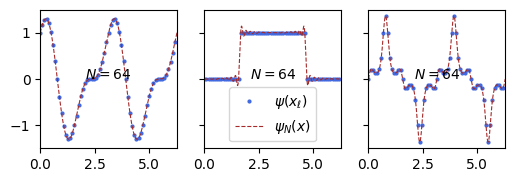

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (6,1.8), sharex = True, sharey = True)
Num = 2**6
x_points = np.linspace(0,np.pi *2, Num,endpoint= False)
x = np.linspace(0,2 * np.pi, 2000)
functions = [u1, u2, u3]
cmap = plt.get_cmap('tab10')
color = [cmap(i) for i in range(2)]

for k in range(3) :
    coeffs = fourier_coeffs(functions[k], N = Num)
    ax[k].plot(x_points, functions[k](x_points), lw = 0, color = 'royalblue', markersize = 2, marker = 'o')
    ax[k].plot(x, interpolant_fft(coeffs, x, N = Num).real,'--', lw = .8, markersize = 2,color = 'brown')
    ax[k].set_xlim(0, 2 * np.pi)
    ax[k].text(np.pi, 0, f"$N = {Num}$", ha = 'center')

ax[1].legend([r'$\psi(x_{\ell})$', r'$\psi_N(x)$'], loc = 'lower center')

## Dérivé de l'interpolant 

**Question 4 :** En notant que la dérivée de l'interpolant de Fourier est donnée par :
\begin{equation}
\frac{\partial}{\partial x} \mathrm{I}_N\psi(t,x)   =\sum_{i=-N/2}^{N/2 - 1} \hat{\psi}_k(t) (i k e^{i k x})
\end{equation}
Implémenter une fonction qui calcule les coefficients de fourier de la dérivée de l'interpolant

In [ ]:
def der_interpolant_coeff(expansion_coeffs : np.ndarray, N : int = 256) :
    # À compléter ...

## Équation d'onde et intégration

**Question 5 :** On se propose maintenant d'étudier la propagation d'une onde en 1d comme dans le TD 1 : 

\begin{equation}
    \frac{\partial^2\psi}{\partial t^2} = c^2 \frac{\partial^2\psi}{\partial x^2}
\end{equation}

On donne la fonction permettant d'initialiser les coefficients de fourier à l'aide d'une méthode RK2. Écrire une fonction permettant d'intégrer temporellement les coefficients de Fourier de l'interpolant à l'aide d'un shéma centré d'ordre 2. 

In [7]:
c = 1
N = 512
dt = 0.001
T = 1
num_steps = int(T/dt)
psi_coeff = np.empty((num_steps, N), dtype = np.complex128)

In [8]:
def wrap_dist(x, x0, L=2*np.pi):
    return (x - x0 + L/2) % L - L/2

x0 = 1.4
sigma = 0.3
k0 = 128

def psi_initial(x):
    d = wrap_dist(x, x0)
    return np.exp(-(d**2)/(2*sigma**2)) * np.cos(k0*d)

def analytical_solution(x, t, c=1.0):
    """
    Exact right-moving solution of u_tt = c^2 u_xx:
        u(x,t) = f(x - c t)
    on a periodic domain.
    """
    return psi_initial(x - c*t)

def psi_initial_velocity(x):
    d = wrap_dist(x, x0)
    g = np.exp(-(d**2)/(2*sigma**2))
    # derivative of psi_initial
    dpsi = g * (-(d/sigma**2)*np.cos(k0*d) - k0*np.sin(k0*d))
    return -c * dpsi   # right-moving packet
psi_coeff[0] = fourier_coeffs(psi_initial, N)
dt_psi_coeff = fourier_coeffs(psi_initial_velocity, N)

In [9]:
def initialize_first_step(coeffs_interpolants, dtpsi_coeff, dt, c, N):
    """
    Initialize coeffs_interpolants[1] ] using the initial velocity coefficients  and the wave speed c.
    """
    coeffs_dx0  = der_interpolant_coeff(coeffs_interpolants[0], N)
    coeffs_dx20 = der_interpolant_coeff(coeffs_dx0, N)

    coeffs_interpolants[1] = (
        coeffs_interpolants[0]
        + dt * dtpsi_coeff
        + 0.5 * (dt**2) * (c**2) * coeffs_dx20
    )

In [10]:
initialize_first_step(psi_coeff, dt_psi_coeff, dt, c, N)

In [ ]:
def integration_interpolant_coeffs(coeffs_interpolants, dt, step) : 
    """
    integration_interpolant compute the expansion 's coefficients of u'
    """
    coeffs_dx = der_interpolant_coeff(coeffs_interpolants[step], N)
    coeffs_dx2 = der_interpolant_coeff(coeffs_dx, N)

   # À compléter ...

In [12]:
for step in range(1, num_steps - 1) :
    integration_interpolant_coeffs(psi_coeff, dt, step)

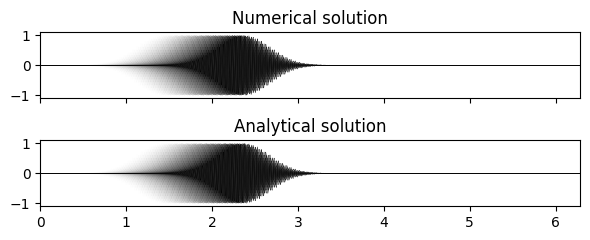

In [13]:
fig, ax = plt.subplots(2,1, figsize = (6,2.5), sharex = True, sharey = True)
x = np.linspace(0,2 * np.pi, 2000)
index = range(0, psi_coeff.shape[0], 20)
cmap = plt.get_cmap('Greys')
color = [cmap(i) for i in np.linspace(0,1, len(index))]
for k, col in zip(index, color) :
    ax[0].plot(x, interpolant_fft(psi_coeff[k], x, N = N).real,'-', lw = .3, markersize = 2,color = col)
    ax[0].set_xlim(0, 2 * np.pi)
    ax[1].plot(x, analytical_solution(x, k*dt, c),'-', lw = .3, markersize = 2,color = col)
ax[1].set_title('Analytical solution')
ax[0].set_title('Numerical solution')
plt.tight_layout()


**Question 6 :** Quelle est la différence principale avec le td 1 ? Comment expliquez vous cela ?

 **Question 7 :** Augmentez le pas de temps, qu'observez-vous ? Donnez une explication claire de ce phénomène

## Méthodes pseudo-spectrales

Nous avons vu que les méthodes pseudo spectrales nous permettaient d'eviter d'avoir à calculer un produit de convolution en repassant dans l'espace réel pour le calcul des termes non linéaires. Nous allons illustrer proprement ce type d'algorithme en s'intéressant à la PDE suivante : 

\begin{equation}
    \frac{\partial \omega}{\partial t} + \boldsymbol{u}\cdot \nabla \omega = \nu \Delta \omega
\end{equation}

où $$\mathbf{u}=(u,v)=(-\partial_y \psi,\partial_x \psi) \quad \text{et} \quad \omega(x,y,t) = \Delta \psi$$

La dynamique dans l'espace spectral s'écrit alors
$$\frac{\mathrm{d} \hat{\omega}_{k,l}}{\mathrm{d} t}= -\widehat{\mathbf{u}\cdot \nabla \omega} \big|_{k,l}-\nu \hat{\omega}_{k,l}(k ^2+l^2)$$

**Question 8 :** Nous itiliserons un algorithme d'euler Forward pour l'intégration temporelle de tous les termes, écrire l'équation de la dynamique spectral discrétisée 

**Question 9 :** on donne les fonctions permettant d'initialiser la transformée de fourier 2d $\hat{\omega}_{k,l}$, compléter la fonction d'intégration pour une étape : 

In [ ]:
Lx,Ly = 2*np.pi, 2*np.pi
nx,ny = 128   , 128    
dx,dy = Lx/nx  , Ly/ny
T = 50      
dt = 3e-3
number_time_steps  = int(T/dt); 
nu = 3.e-4   

# compute domain axis points 
x=np.linspace(0,Lx,nx)
y=np.linspace(0,Ly,ny)
xg,yg = np.meshgrid(x,y)

# compute wavenumber vectors 
kx = np.fft.fftfreq(nx,dx)*2*np.pi
ky = np.fft.fftfreq(ny,dy)*2*np.pi
kx_grid,ky_grid = np.meshgrid(kx, ky)
k_norm = np.sqrt(kx_grid**2 + ky_grid**2)
kinvg = 1./(k_norm + 1e-12)
kinvg[0,0] = 0

coeffs_interpolants = np.empty((number_time_steps, nx, ny), dtype = np.complex128)

In [15]:
def two_d_fourier_coeffs(q):
    return np.fft.fft2(q)

def two_d_values_from_coeffs(coeffs):
    return np.real(np.fft.ifft2(coeffs))

def compute_velocity_from_vorticity(qfft):
    psifft = -qfft * kinvg**2
    ufft = - 1j * ky_grid * psifft
    vfft = 1j * kx_grid * psifft
    return ufft, vfft

def compute_nonlinear_term(qfft, ufft, vfft):
    u = two_d_values_from_coeffs(ufft)
    v = two_d_values_from_coeffs(vfft)
    q = two_d_values_from_coeffs(qfft)

    nonlinear_term = 1j*kx_grid* two_d_fourier_coeffs(u*q) + 1j*ky_grid*two_d_fourier_coeffs(v*q)
    return nonlinear_term

def compute_initial_condition() : 
    q = np.random.normal(size=[ny,nx])
    coeffs_interpolants[0] = two_d_fourier_coeffs(q)



In [1]:
def integration_interpolant_coeffs(coeffs_interpolants, dt, step): 
    """
    integration_interpolant compute the expansion 's coefficients of q^n
    """
    ufft, vfft = compute_velocity_from_vorticity(coeffs_interpolants[step])
    nonlinear_term = compute_nonlinear_term(coeffs_interpolants[step], ufft, vfft)
    
    # À compléter

**Question 10 :** Try to run the code below, what do you observe : 

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [25]:
def integrate() :
    compute_initial_condition()
    for step in range(number_time_steps - 1) :
        integration_interpolant_coeffs(coeffs_interpolants, dt, step)

def plot_evolution_animation(coeffs_interpolants):
    frames = range(0, number_time_steps, 400)
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi = 100)
    coeff0 = coeffs_interpolants[0]
    q0 = two_d_values_from_coeffs(coeff0)

    im0 = axes[0].imshow(
        q0,
        origin='lower',
        extent=[0, Lx, 0, Ly],
        vmin=-.5,
        vmax=.5,
        animated=True,
        cmap = 'bwr'
    )
    title0 = axes[0].set_title(f"q : t = {0*dt:.2f}")

    # Fourier-space power
    power0 = np.log(np.abs(coeff0)**2 + 1e-14)
    power = np.fft.fftshift(power0)
    im1 = axes[1].imshow(
        power,
        origin='lower',
        extent=[kx_grid.min(), kx_grid.max(), ky_grid.min(), ky_grid.max()],
        aspect='auto',
        cmap='bwr',
        animated=True,
    )
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[1].set_xlabel(r"$k_x$")
    axes[1].set_ylabel(r"$k_y$")
    im1.set_clim(vmin=0, vmax=5)
    title1 = axes[1].set_title(f"Fourier-space E : t = {0*dt:.2f}")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    def update(frame):
        print(f"Updating frame {frame}/{frames[-1]}", end='\r')
        coeffs = coeffs_interpolants[frame]
        q = two_d_values_from_coeffs(coeffs)
        im0.set_data(q)
        ufft, vfft = compute_velocity_from_vorticity(coeffs)
        energy = 0.5 * (np.abs(ufft)**2 + np.abs(vfft)**2)
        im1.set_data(np.fft.fftshift(energy))
        title0.set_text(f"q : t = {frame*dt:.2f}")
        title1.set_text(f"Fourier-space E : t = {frame*dt:.2f}")
        return im0, im1, title0, title1

    anim = FuncAnimation(
        fig,
        update,
        frames=frames,
        blit=True,
        interval=50
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [ ]:
integrate()

In [27]:
plot_evolution_animation(coeffs_interpolants)